In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI ML/collab/week4/Copy of devnagari digit.zip'
extraction_path = '/content/drive/MyDrive/AI ML/collab/week4/extracted_devnagari_digit'

# Create the directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}' successfully.")

# List contents of the extracted directory to verify
print(f"Contents of '{extraction_path}':")
for root, dirs, files in os.walk(extraction_path):
    level = root.replace(extraction_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

Streaming output truncated to the last 5000 lines.
                10301.png
                10302.png
                10303.png
                10304.png
                10306.png
                10307.png
                104017.png
                104018.png
                104019.png
                104021.png
                104023.png
                104024.png
                104025.png
                104026.png
                104027.png
                104028.png
                104029.png
                104030.png
                104031.png
                104032.png
                104033.png
                104034.png
                104057.png
                104058.png
                104059.png
                104060.png
                104061.png
                104062.png
                104065.png
                104066.png
                104067.png
                104068.png
                104069.png
                104070.png
                104071.png
          

In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


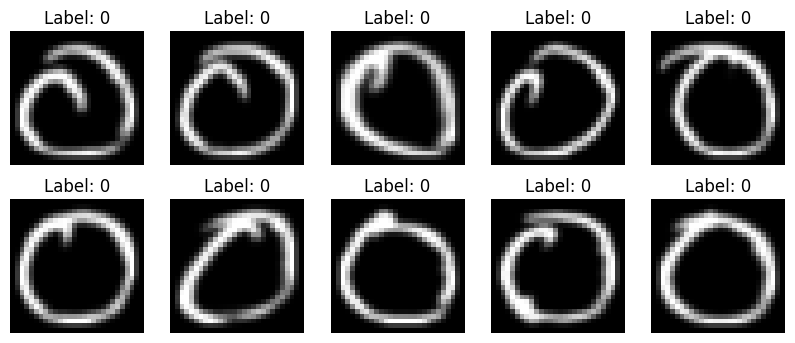

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI ML/collab/week4/extracted_devnagari_digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI ML/collab/week4/extracted_devnagari_digit/DevanagariHandwrittenDigitDataset/Test"
# Define image size
img_height, img_width = 28, 28
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28* 28)
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
dataset_root = "/content/drive/MyDrive/AI ML/collab/week4/extracted_devnagari_digit/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(dataset_root, "Train")
test_dir = os.path.join(dataset_root, "Test")

print("Train dir:", train_dir)
print("Test dir :", test_dir)
print("Train exists?", os.path.exists(train_dir))
print("Test exists? ", os.path.exists(test_dir))

Train dir: /content/drive/MyDrive/AI ML/collab/week4/extracted_devnagari_digit/DevanagariHandwrittenDigitDataset/Train
Test dir : /content/drive/MyDrive/AI ML/collab/week4/extracted_devnagari_digit/DevanagariHandwrittenDigitDataset/Test
Train exists? True
Test exists?  True


In [ ]:
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(
        [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))]
    )
    class_map = {name: i for i, name in enumerate(class_names)}

    print("Class map:", class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img, dtype=np.float32) / 255.0
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)

In [ ]:
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

Class map: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Class map: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
x_train: (17000, 28, 28)
y_train: (17000,)
x_test : (3000, 28, 28)
y_test : (3000,)


In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Processed x_train:", x_train.shape)
print("Processed y_train:", y_train_cat.shape)
print("Processed x_test :", x_test.shape)
print("Processed y_test :", y_test_cat.shape)

Processed x_train: (17000, 28, 28, 1)
Processed y_train: (17000, 10)
Processed x_test : (3000, 28, 28, 1)
Processed y_test : (3000, 10)


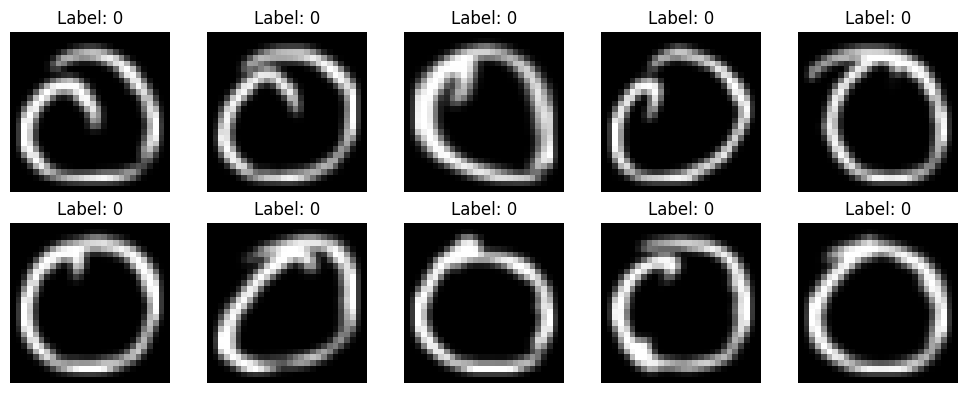

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train_cat[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation="sigmoid"),
    Dense(128, activation="sigmoid"),
    Dense(256, activation="sigmoid"),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    ModelCheckpoint("best_devnagari_fcn.keras", save_best_only=True, monitor="val_loss"),
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history = model.fit(
    x_train,
    y_train_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4236 - loss: 1.7269 - val_accuracy: 0.0000e+00 - val_loss: 6.3080
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8076 - loss: 0.6046 - val_accuracy: 0.0000e+00 - val_loss: 7.1984
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9164 - loss: 0.2977 - val_accuracy: 0.0000e+00 - val_loss: 7.8416
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9438 - loss: 0.1985 - val_accuracy: 0.0000e+00 - val_loss: 8.3485
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9563 - loss: 0.1507 - val_accuracy: 0.0000e+00 - val_loss: 8.5661


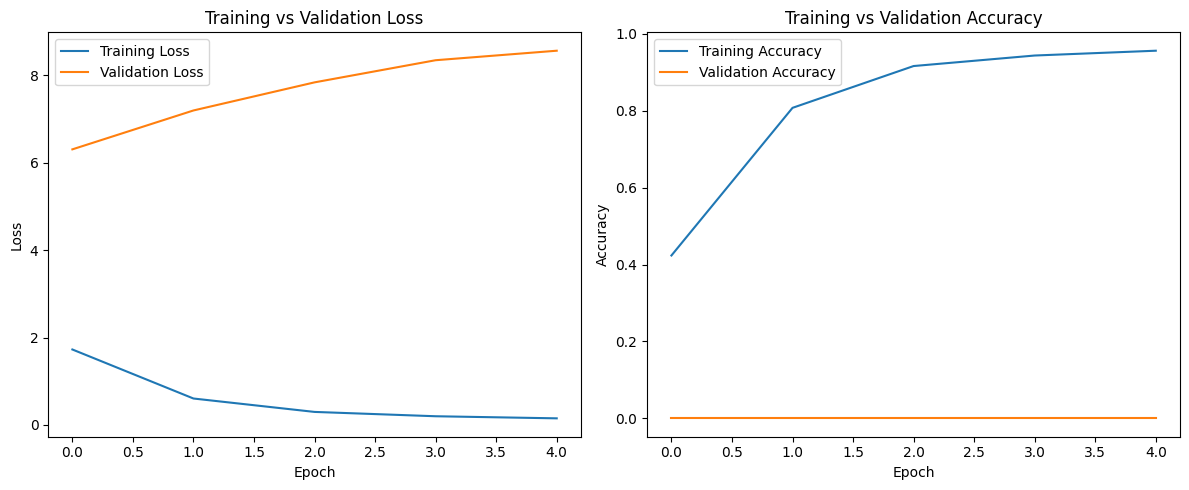

In [ ]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 3ms/step - accuracy: 0.5730 - loss: 2.0358
Test Loss: 2.0358
Test Accuracy: 0.5730


In [ ]:
model.save("devnagari_fcn_model.h5")
print("Saved as devnagari_fcn_model.h5")

Saved as devnagari_fcn_model.h5


In [ ]:
loaded_model = tf.keras.models.load_model("devnagari_fcn_model.h5")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

94/94 - 1s - 8ms/step - accuracy: 0.5730 - loss: 2.0358
Loaded Model Test Loss: 2.0358
Loaded Model Test Accuracy: 0.5730


In [ ]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print("First 10 predicted labels:", predicted_labels[:10])
print("First 10 true labels     :", y_test[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
First 10 predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 true labels     : [0 0 0 0 0 0 0 0 0 0]


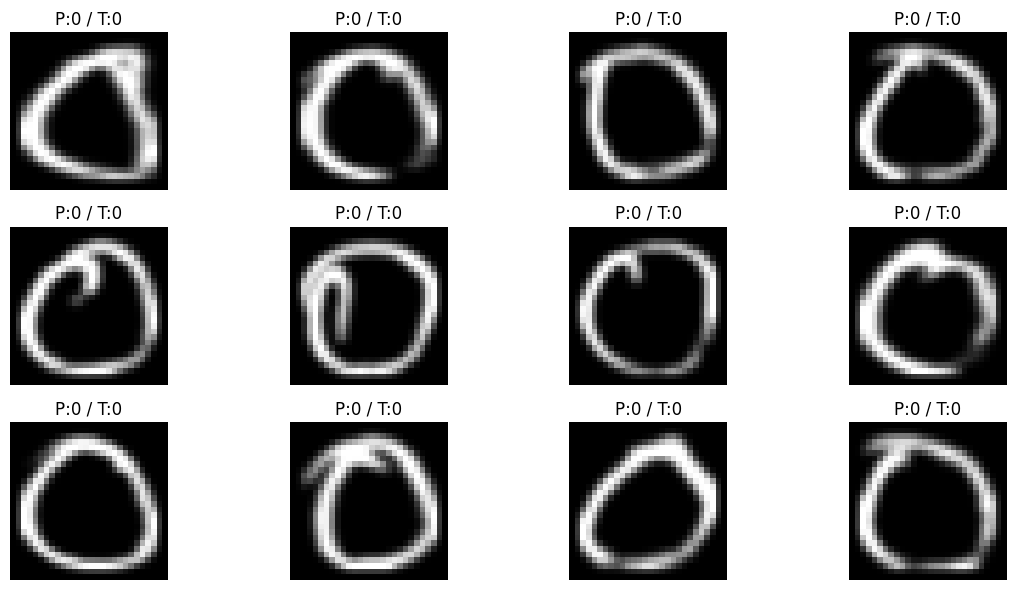

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(min(12, len(x_test))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"P:{predicted_labels[i]} / T:{y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()